# 02 — Label Engineering

Derive the five multi-label fraud labels from raw Sparkov features.
**This notebook must be run before any modelling notebook.**

Labels derived here:
| Label | Name | Gated on `is_fraud`? |
|---|---|---|
| `L_V` | Velocity burst | Yes |
| `L_G` | Geographic anomaly | No |
| `L_C` | Category anomaly | No |
| `L_R` | Ring membership | Yes |
| `L_T` | Temporal anomaly | No |

**Output:** `data/processed/train_labeled.parquet`, `data/processed/test_labeled.parquet`

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')

from src.labels import derive_labels, LABEL_COLS
from src.evaluation import label_cooccurrence_matrix, cross_border_stats

In [2]:
train = pd.read_csv('../data/raw/fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time', 'dob'])
test  = pd.read_csv('../data/raw/fraudTest.csv',  index_col=0, parse_dates=['trans_date_trans_time', 'dob'])
print(f'Train: {len(train):,} | Test: {len(test):,}')

Train: 1,296,675 | Test: 555,719


In [3]:
# Derive labels — this is the only place labels are created
# All thresholds are fixed constants in src/labels.py
train_labeled = derive_labels(train)
test_labeled  = derive_labels(test)

Deriving labels:   0%|                                 | 0/5 [00:00<?, ?label/s]


[Velocity burst  ]

[Geographic anom.]

[Category anomaly]


  L_C per card:   0%|                                 | 0/983 [00:00<?, ?card/s]


[Ring membership ]


  L_R per merchant:   0%|                            | 0/679 [00:00<?, ?merch/s]

...


[Velocity burst  ]

[Geographic anom.]

[Category anomaly]


  L_C per card:   0%|                                 | 0/924 [00:00<?, ?card/s]


[Ring membership ]


  L_R per merchant:   0%|                            | 0/557 [00:00<?, ?merch/s]


[Temporal anomaly]

Label prevalence:
  L_V: 157 (0.03%)
  L_G: 0 (0.00%)
  L_C: 496,173 (89.28%)
  L_R: 0 (0.00%)
  L_T: 495 (0.09%)
  cross_border (|L|≥2): 515 (0.09%)


In [ ]:
# Validate prevalence. Gated labels (L_V, L_R) are capped at the fraud rate, so
# judge them as a share of fraud; ungated labels (L_G, L_C, L_T) as a share of
# all txns — flag both starved (<1%) and saturated (>50%).
GATED = {'L_V', 'L_R'}
n_fraud = int(train_labeled['is_fraud'].sum())
for col in LABEL_COLS:
    pos = int(train_labeled[col].sum())
    if col in GATED:
        pct = pos / n_fraud * 100
        flag = 'LOW' if pct < 1.0 else 'OK'
        print(f'{col}: {pos:>7,} = {pct:5.2f}% of fraud   {flag}')
    else:
        pct = pos / len(train_labeled) * 100
        flag = 'LOW' if pct < 1.0 else ('SATURATED' if pct > 50.0 else 'OK')
        print(f'{col}: {pos:>7,} = {pct:5.2f}% of txns    {flag}')

print('\nCross-border stats:')
print(cross_border_stats(train_labeled))

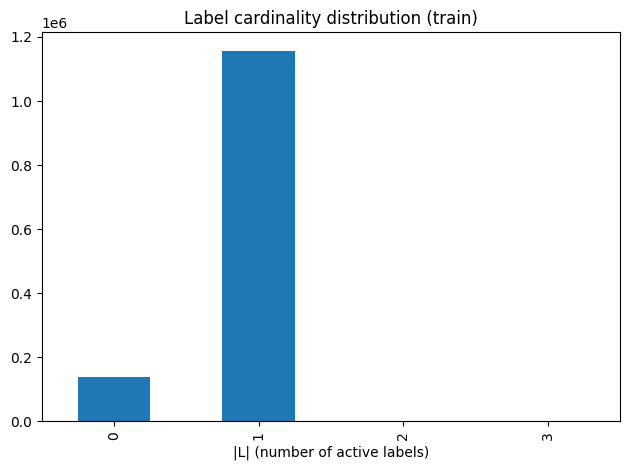

In [5]:
# Label cardinality distribution
import matplotlib.pyplot as plt
train_labeled['label_cardinality'].value_counts().sort_index().plot(
    kind='bar', title='Label cardinality distribution (train)'
)
plt.xlabel('|L| (number of active labels)')
plt.tight_layout()

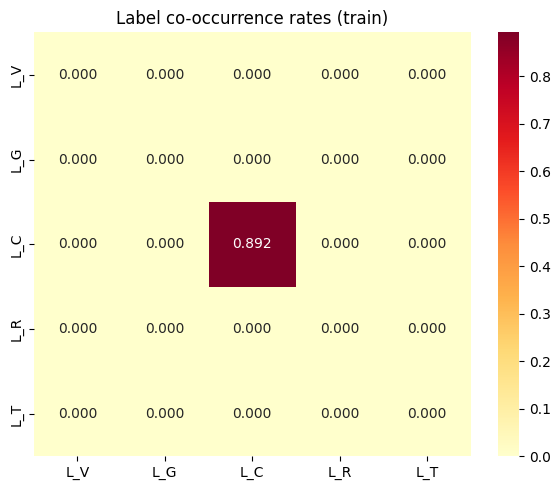

In [6]:
# Label co-occurrence matrix
import seaborn as sns
y = train_labeled[LABEL_COLS].values
cooc = label_cooccurrence_matrix(y, LABEL_COLS)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cooc, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Label co-occurrence rates (train)')
plt.tight_layout()

In [7]:
# Save to processed
train_labeled.to_parquet('../data/processed/train_labeled.parquet', index=False)
test_labeled.to_parquet('../data/processed/test_labeled.parquet', index=False)
print('Saved.')

Saved.
